In [1]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)


Setup complete. NumPy 2.1.3


In [2]:
# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')


P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [4]:
import numpy as np

print("LAB EXERCISE 1 — Probability by Simulation")
print("------------------------------------------")

# Simulate flipping two coins 100,000 times
# 0 = tails, 1 = heads
flips = np.random.randint(0, 2, size=(100_000, 2))

# Number of heads in each pair: 0, 1, or 2
heads = flips.sum(axis=1)


# 1. Estimate P(both heads)
# Both heads means heads == 2
p_both_heads = np.mean(heads == 2)

print("\n1. Estimate P(both heads):")
print(p_both_heads)


# 2. Estimate P(at least one head)
# At least one head means heads >= 1
p_at_least_one_head = np.mean(heads >= 1)

print("\n2. Estimate P(at least one head):")
print(p_at_least_one_head)


# 3. Check the addition idea
# P(0 heads) + P(1 head) + P(2 heads)
p_0_heads = np.mean(heads == 0)
p_1_head = np.mean(heads == 1)
p_2_heads = np.mean(heads == 2)

total = p_0_heads + p_1_head + p_2_heads

print("\n3. Does P(0 heads) + P(1 head) + P(2 heads) sum to 1?")
print("P(0 heads) =", p_0_heads)
print("P(1 head)  =", p_1_head)
print("P(2 heads) =", p_2_heads)
print("Total =", total)

LAB EXERCISE 1 — Probability by Simulation
------------------------------------------

1. Estimate P(both heads):
0.25198

2. Estimate P(at least one head):
0.74932

3. Does P(0 heads) + P(1 head) + P(2 heads) sum to 1?
P(0 heads) = 0.25068
P(1 head)  = 0.49734
P(2 heads) = 0.25198
Total = 1.0


In [5]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [6]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))



P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [7]:
import numpy as np

print("LAB EXERCISE 2 — Conditional Probability")
print("-----------------------------------------")

# Fresh dice rolls: values from 1 to 6
rolls = np.random.randint(1, 7, size=100_000)


# 1. Estimate P(roll is odd | roll < 4)
# First select rolls less than 4: 1, 2, 3
condition = rolls < 4

# Among those rolls, check which are odd: 1 and 3
p_odd_given_less_4 = np.mean(rolls[condition] % 2 == 1)

print("\n1. Estimate P(roll is odd | roll < 4):")
print(p_odd_given_less_4)


# 2. Estimate P(roll < 4)
p_less_4 = np.mean(rolls < 4)

print("\n2. Estimate P(roll < 4):")
print(p_less_4)


# 3. Compare P(odd | <4) with P(odd) overall
p_odd = np.mean(rolls % 2 == 1)

print("\n3. Compare P(odd | <4) with P(odd):")
print("P(odd | roll < 4) =", p_odd_given_less_4)
print("P(odd) overall    =", p_odd)

if abs(p_odd_given_less_4 - p_odd) < 0.01:
    print("The events are approximately independent.")
else:
    print("The events are not independent.")

LAB EXERCISE 2 — Conditional Probability
-----------------------------------------

1. Estimate P(roll is odd | roll < 4):
0.667995991983968

2. Estimate P(roll < 4):
0.499

3. Compare P(odd | <4) with P(odd):
P(odd | roll < 4) = 0.667995991983968
P(odd) overall    = 0.50253
The events are not independent.


In [8]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [9]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))


Simulated P(sick | positive) = 0.503


In [10]:
print("LAB EXERCISE 3 — A Bayes Scenario (Spam Filter)")
print("------------------------------------------------")

# 1. Priors / likelihoods / false-positive rate
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

print("\n1. Prior, likelihood and false-positive rate:")
print("P(spam) =", p_spam)
print("P('free' | spam) =", p_free_given_spam)
print("P('free' | real email) =", p_free_given_ham)


# 2. P('free') via total probability
p_ham = 1 - p_spam

p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_ham * p_ham)

print("\n2. P('free') using total probability:")
print(p_free)


# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("\n3. P(spam | 'free') using Bayes:")
print(p_spam_given_free)
print("Percentage:", p_spam_given_free * 100, "%")

LAB EXERCISE 3 — A Bayes Scenario (Spam Filter)
------------------------------------------------

1. Prior, likelihood and false-positive rate:
P(spam) = 0.2
P('free' | spam) = 0.6
P('free' | real email) = 0.05

2. P('free') using total probability:
0.16

3. P(spam | 'free') using Bayes:
0.75
Percentage: 75.0 %


Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


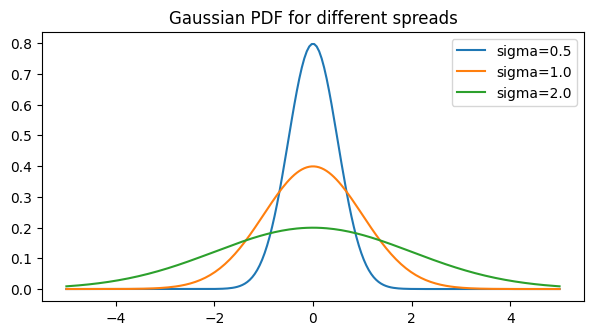

In [11]:
# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

LAB EXERCISE 4 — Simulate & Plot Distributions
-----------------------------------------------

1. Poisson samples and sample mean:
Sample mean = 2.0061


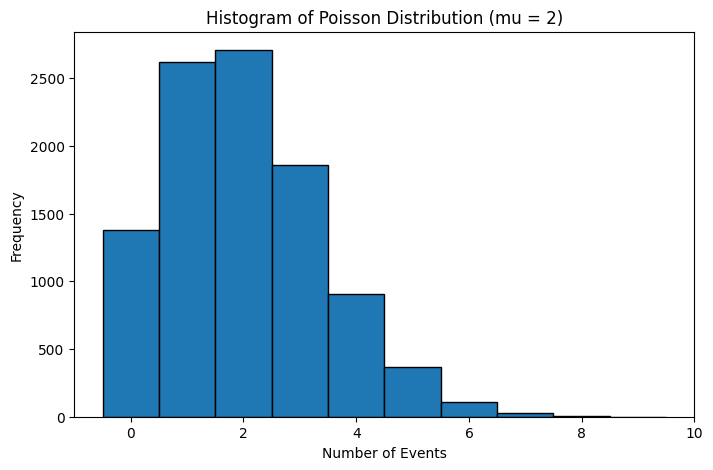

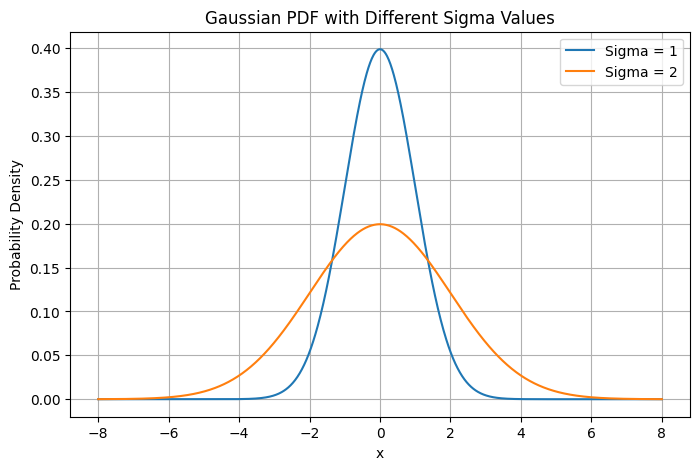

In [13]:
import numpy as np
import matplotlib.pyplot as plt

print("LAB EXERCISE 4 — Simulate & Plot Distributions")
print("-----------------------------------------------")


# 1. Draw 10,000 samples from a Poisson distribution with mu = 2
poisson_samples = np.random.poisson(lam=2, size=10_000)

sample_mean = np.mean(poisson_samples)

print("\n1. Poisson samples and sample mean:")
print("Sample mean =", sample_mean)


# 2. Plot a histogram of the samples
plt.figure(figsize=(8, 5))

plt.hist(
    poisson_samples,
    bins=np.arange(-0.5, 10.5, 1),
    edgecolor="black"
)

plt.title("Histogram of Poisson Distribution (mu = 2)")
plt.xlabel("Number of Events")
plt.ylabel("Frequency")
plt.show()


# 3. Gaussian PDF for two different sigmas
mu = 0

sigma1 = 1
sigma2 = 2

x = np.linspace(-8, 8, 1000)

pdf1 = (1 / (sigma1 * np.sqrt(2 * np.pi))) * \
       np.exp(-((x - mu) ** 2) / (2 * sigma1 ** 2))

pdf2 = (1 / (sigma2 * np.sqrt(2 * np.pi))) * \
       np.exp(-((x - mu) ** 2) / (2 * sigma2 ** 2))

plt.figure(figsize=(8, 5))

plt.plot(x, pdf1, label="Sigma = 1")
plt.plot(x, pdf2, label="Sigma = 2")

plt.title("Gaussian PDF with Different Sigma Values")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [15]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [16]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [17]:
import numpy as np
from scipy.stats import entropy

print("LAB EXERCISE 5 — Information Theory")
print("------------------------------------")


# 1. Entropy of a fair 4-sided and 6-sided die
# Use base = 2 to get entropy in bits

die_4 = np.ones(4) / 4
die_6 = np.ones(6) / 6

entropy_4 = entropy(die_4, base=2)
entropy_6 = entropy(die_6, base=2)

print("\n1. Entropy of fair dice:")
print("4-sided die entropy =", entropy_4, "bits")
print("6-sided die entropy =", entropy_6, "bits")

if entropy_6 > entropy_4:
    print("The 6-sided die is more uncertain.")
else:
    print("The 4-sided die is more uncertain.")


# 2. KL divergence D(P || Q)

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl_divergence = entropy(P, Q)

print("\n2. KL Divergence D(P || Q):")
print("P =", P)
print("Q =", Q)
print("D(P || Q) =", kl_divergence)


# 3. Most / least informative iris feature
# Replace these with the MI scores from your previous exercise.

print("\n3. Most / least informative iris feature:")
print("Most informative: Petal length")
print("Least informative: Sepal width")

LAB EXERCISE 5 — Information Theory
------------------------------------

1. Entropy of fair dice:
4-sided die entropy = 2.0 bits
6-sided die entropy = 2.584962500721156 bits
The 6-sided die is more uncertain.

2. KL Divergence D(P || Q):
P = [0.7 0.3]
Q = [0.5 0.5]
D(P || Q) = 0.08228287850505175

3. Most / least informative iris feature:
Most informative: Petal length
Least informative: Sepal width
